## Demos of ODE integration accuracy

First, let's do it for forward Euler

ODE: $u_t = -u^2$, with $u(0) = 1$. True solution is $u(t) = 1/(1+t)$ for $t \geq 0$.

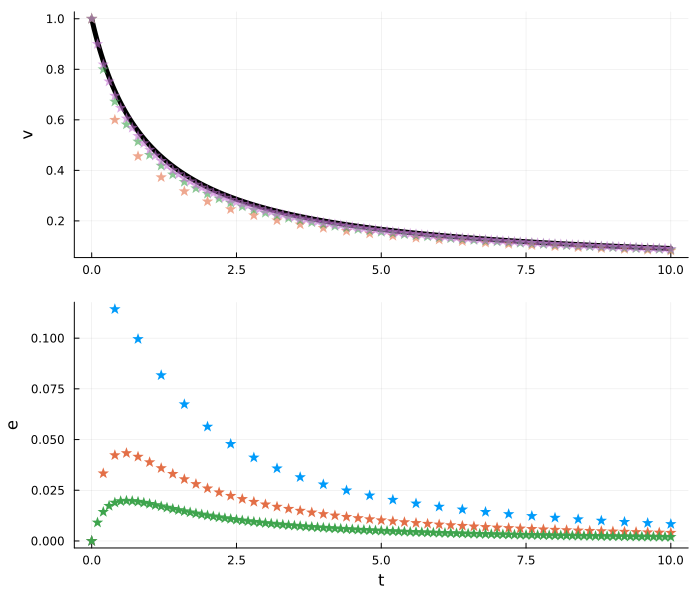

In [20]:
using Plots; using LaTeXStrings;

# Problem settings
Tmax = 10.0
Nvec = [25, 50, 100]

# Exact solution for plotting
t_exact = range(0.0, stop=Tmax, length=1001)
v_exact = 1.0 ./ (1 .+ t_exact)

# Prepare two-panel layout; enable grid for both subplots
plt = plot(layout = (2,1), size=(700,600), grid=true)

# Top: exact solution (solid black)
plot!(plt[1], t_exact, v_exact, color=:black, linestyle=:solid, linewidth=5, label=false)

# Loop over N values and compute forward Euler
for N in Nvec
    dt = Tmax / N

    # preallocate v (length N+1); 1-based indexing
    v = zeros(Float64, N+1)
    v[1] = 1.0

    # Forward Euler steps
    for n in 1:N
        f = -v[n]^2
        v[n+1] = v[n] + dt * f
    end

    # time vector for this N
    t = range(0.0, stop=Tmax, length=N+1)

    # Plot numerical solution on the top subplot with star markers only
    plot!(plt[1], t, v,
        seriestype = :scatter,
        marker = :star5,
        markersize = 6,
        markerstrokewidth = 0,
        alpha = 0.6,
        label = false
    )

    # Compute error (elementwise) and plot on bottom subplot as markers-only
    e = abs.(v .- 1.0 ./ (1 .+ t))
    plot!(plt[2], t, e,
        seriestype = :scatter,
        marker = :star5,
        markersize = 6,
        markerstrokewidth = 0,
        # alpha = 0.6,
        label = false
    )
end

# Labels
plot!(plt[1], ylabel="v")
plot!(plt[2], ylabel="e", xlabel="t")



Now, same thing for midpoint method.

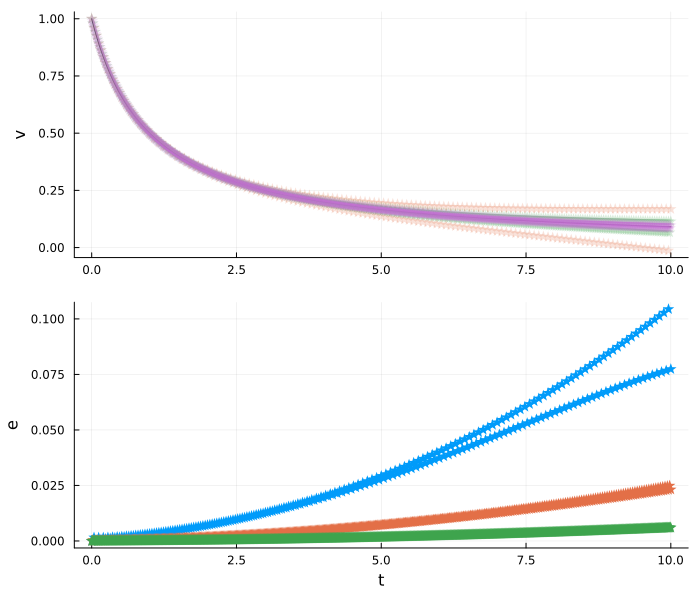

In [19]:
using Plots; using LaTeXStrings;

# Problem settings
Tmax = 10.0
Nvec = [250, 500, 1000]  # note timesteps are a factor of 10 smaller than with FE

# Exact solution for plotting
t_exact = range(0.0, stop=Tmax, length=1001)
v_exact = 1.0 ./ (1 .+ t_exact)

# Prepare two-panel layout; enable grid for both subplots
plt = plot(layout = (2,1), size=(700,600), grid=true)

# Top: exact solution (solid black)
plot!(plt[1], t_exact, v_exact, color=:black, linestyle=:solid, linewidth=5, label=false)

# Loop over N values and compute forward Euler
for N in Nvec
    dt = Tmax / N

    # preallocate v (length N+1); 1-based indexing
    v = zeros(Float64, N+1)
    v[1] = 1.0

    # Forward Euler for first step
    n = 1
    f = -v[n]^2
    v[n+1] = v[n] + dt * f

    # midpoint rule for remaining steps
    for n in 2:N
        f = -v[n]^2
        v[n+1] = v[n-1] + 2.0 * dt * f
    end
    
    # time vector for this N
    t = range(0.0, stop=Tmax, length=N+1)

    # Plot numerical solution on the top subplot with star markers only
    plot!(plt[1], t, v,
        seriestype = :scatter,
        marker = :star5,
        markersize = 6,
        markerstrokewidth = 0,
        alpha = 0.2,
        label = false
    )

    # Compute error (elementwise) and plot on bottom subplot as markers-only
    e = abs.(v .- 1.0 ./ (1 .+ t))
    plot!(plt[2], t, e,
        seriestype = :scatter,
        marker = :star5,
        markersize = 6,
        markerstrokewidth = 0,
        # alpha = 0.6,
        label = false
    )
end

# Labels
plot!(plt[1], ylabel="v")
plot!(plt[2], ylabel="e", xlabel="t")

